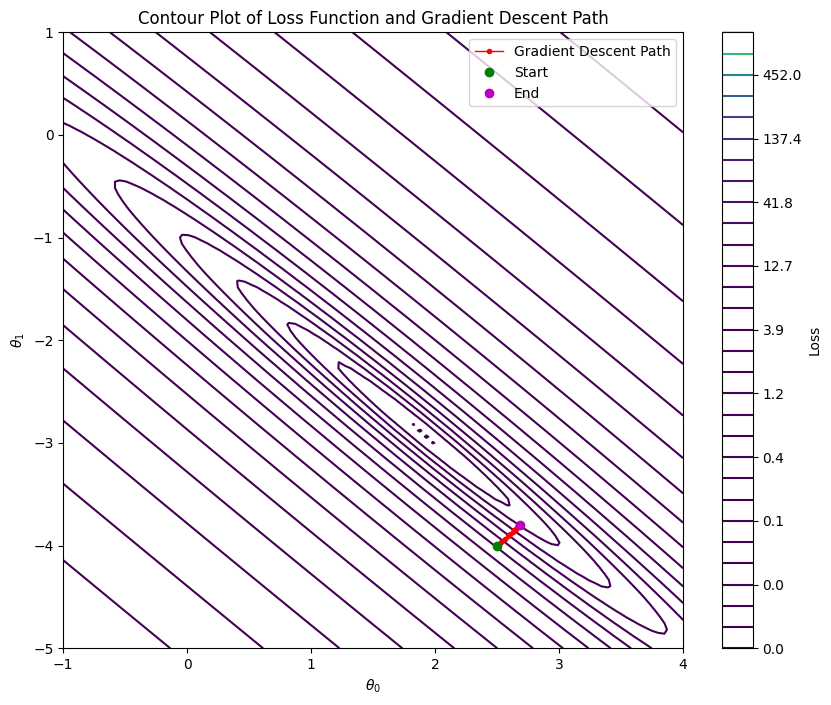

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Generate synthetic data with multicollinearity
np.random.seed(0)
N = 100  # Number of data points
X1 = np.random.uniform(-1, 1, N)
X2 = X1 + np.random.normal(0, 0.1, N)  # X2 is highly correlated with X1
X = np.vstack((X1, X2)).T
theta_true = np.array([2, -3])
y = X @ theta_true + np.random.normal(0, 0.1, N)  # y = 2*X1 - 3*X2 + noise

# Define the loss function (MSE)
def compute_loss(theta, X, y):
    return np.mean((X @ theta - y) ** 2)

# Create a grid of theta values for contour plot
theta0_vals = np.linspace(-1, 4, 100)
theta1_vals = np.linspace(-5, 1, 100)
Theta0, Theta1 = np.meshgrid(theta0_vals, theta1_vals)
Loss = np.zeros_like(Theta0)

# Compute loss over the grid
for i in range(len(theta0_vals)):
    for j in range(len(theta1_vals)):
        theta = np.array([Theta0[j, i], Theta1[j, i]])
        Loss[j, i] = compute_loss(theta, X, y)

# Perform gradient descent
def gradient_descent(X, y, theta_init, learning_rate, num_iters):
    theta_history = [theta_init]
    theta = theta_init.copy()
    for _ in range(num_iters):
        gradient = 2 * X.T @ (X @ theta - y) / len(y)
        theta = theta - learning_rate * gradient
        theta_history.append(theta.copy())
    return np.array(theta_history)

# Initialize parameters
theta_init = np.array([2.5, -4])
learning_rate = 0.1
num_iters = 10

# Run gradient descent
theta_history = gradient_descent(X, y, theta_init, learning_rate, num_iters)

# Plotting
plt.figure(figsize=(10, 8))
# Contour plot of the loss function
contour_levels = np.logspace(-2, 3, 30)
plt.contour(Theta0, Theta1, Loss, levels=contour_levels, cmap='viridis')
plt.colorbar(label='Loss')
# Overlay gradient descent path
theta_history = np.array(theta_history)
plt.plot(theta_history[:, 0], theta_history[:, 1], 'ro-', markersize=3, linewidth=1, label='Gradient Descent Path')
# Mark the starting and ending points
plt.plot(theta_history[0, 0], theta_history[0, 1], 'go', label='Start')
plt.plot(theta_history[-1, 0], theta_history[-1, 1], 'mo', label='End')
# True theta
# plt.plot(theta_true[0], theta_true[1], 'yx', markersize=10, label='True Theta')
# Labels and title
plt.xlabel(r'$\theta_0$')
plt.ylabel(r'$\theta_1$')
plt.title('Contour Plot of Loss Function and Gradient Descent Path')
plt.legend()
plt.show()


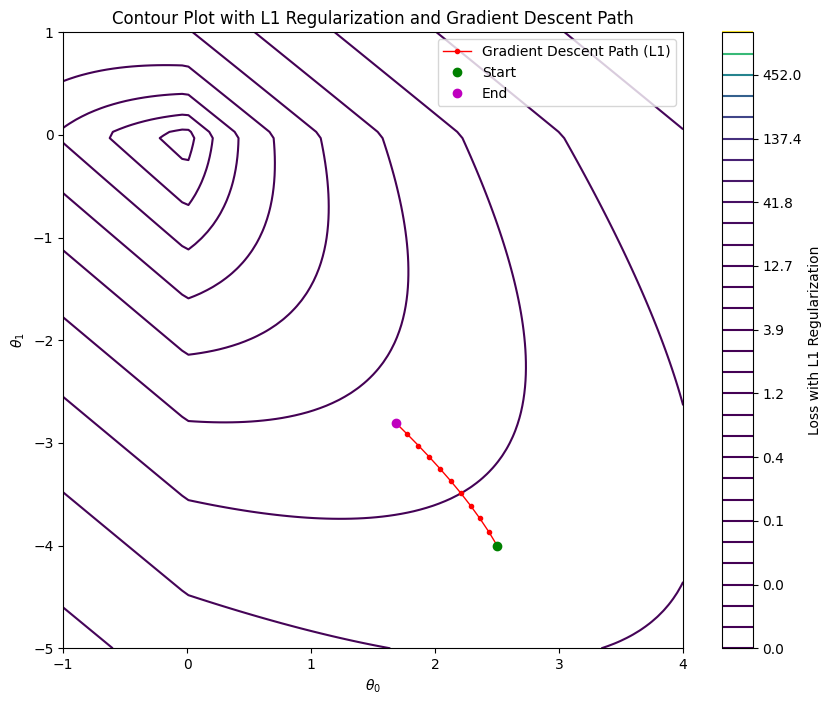

In [38]:
# L1 Regularization (Lasso Regression)

# Regularization parameter
lambda_reg = 1  # Adjust this value to see different effects

# Define the loss function with L1 regularization
def compute_loss_l1(theta, X, y, lambda_reg):
    mse = np.mean((X @ theta - y) ** 2)
    l1_penalty = lambda_reg * np.sum(np.abs(theta))
    return mse + l1_penalty

# Compute loss over the grid with L1 regularization
Loss_l1 = np.zeros_like(Theta0)
for i in range(len(theta0_vals)):
    for j in range(len(theta1_vals)):
        theta = np.array([Theta0[j, i], Theta1[j, i]])
        Loss_l1[j, i] = compute_loss_l1(theta, X, y, lambda_reg)

# Adjust gradient descent function for L1 regularization using subgradient
def gradient_descent_l1(X, y, theta_init, learning_rate, num_iters, lambda_reg):
    theta_history = [theta_init]
    theta = theta_init.copy()
    for _ in range(num_iters):
        gradient = (2 * X.T @ (X @ theta - y)) / len(y)
        # Subgradient for L1 regularization
        subgradient = lambda_reg * np.sign(theta)
        gradient += subgradient
        theta = theta - learning_rate * gradient
        theta_history.append(theta.copy())
    return np.array(theta_history)

# Run gradient descent with L1 regularization
theta_history_l1 = gradient_descent_l1(X, y, theta_init, learning_rate, num_iters, lambda_reg)

# Plotting
plt.figure(figsize=(10, 8))
# Contour plot of the regularized loss function
contour_levels = np.logspace(-2, 3, 30)
plt.contour(Theta0, Theta1, Loss_l1, levels=contour_levels, cmap='viridis')
plt.colorbar(label='Loss with L1 Regularization')
# Overlay gradient descent path
plt.plot(theta_history_l1[:, 0], theta_history_l1[:, 1], 'ro-', markersize=3, linewidth=1, label='Gradient Descent Path (L1)')
# Mark the starting and ending points
plt.plot(theta_history_l1[0, 0], theta_history_l1[0, 1], 'go', label='Start')
plt.plot(theta_history_l1[-1, 0], theta_history_l1[-1, 1], 'mo', label='End')
# True theta
# plt.plot(theta_true[0], theta_true[1], 'yx', markersize=10, label='True Theta')
# Labels and title
plt.xlabel(r'$\theta_0$')
plt.ylabel(r'$\theta_1$')
plt.title('Contour Plot with L1 Regularization and Gradient Descent Path')
plt.legend()
plt.show()


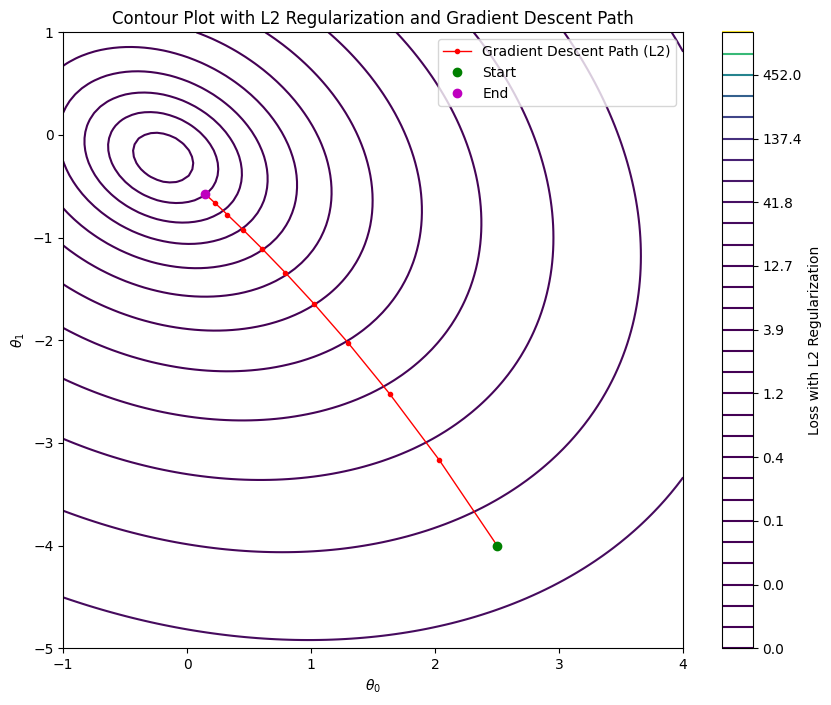

In [39]:
# L2 Regularization (Ridge Regression)

# Regularization parameter
lambda_reg = 1.0  # Adjust this value to see different effects

# Define the loss function with L2 regularization
def compute_loss_l2(theta, X, y, lambda_reg):
    mse = np.mean((X @ theta - y) ** 2)
    l2_penalty = lambda_reg * np.sum(theta ** 2)
    return mse + l2_penalty

# Compute loss over the grid with L2 regularization
Loss_l2 = np.zeros_like(Theta0)
for i in range(len(theta0_vals)):
    for j in range(len(theta1_vals)):
        theta = np.array([Theta0[j, i], Theta1[j, i]])
        Loss_l2[j, i] = compute_loss_l2(theta, X, y, lambda_reg)

# Adjust gradient descent function for L2 regularization
def gradient_descent_l2(X, y, theta_init, learning_rate, num_iters, lambda_reg):
    theta_history = [theta_init]
    theta = theta_init.copy()
    for _ in range(num_iters):
        gradient = (2 * X.T @ (X @ theta - y)) / len(y) + 2 * lambda_reg * theta
        theta = theta - learning_rate * gradient
        theta_history.append(theta.copy())
    return np.array(theta_history)

# Run gradient descent with L2 regularization
theta_history_l2 = gradient_descent_l2(X, y, theta_init, learning_rate, num_iters, lambda_reg)

# Plotting
plt.figure(figsize=(10, 8))
# Contour plot of the regularized loss function
contour_levels = np.logspace(-2, 3, 30)
plt.contour(Theta0, Theta1, Loss_l2, levels=contour_levels, cmap='viridis')
plt.colorbar(label='Loss with L2 Regularization')
# Overlay gradient descent path
plt.plot(theta_history_l2[:, 0], theta_history_l2[:, 1], 'ro-', markersize=3, linewidth=1, label='Gradient Descent Path (L2)')
# Mark the starting and ending points
plt.plot(theta_history_l2[0, 0], theta_history_l2[0, 1], 'go', label='Start')
plt.plot(theta_history_l2[-1, 0], theta_history_l2[-1, 1], 'mo', label='End')
# True theta
# plt.plot(theta_true[0], theta_true[1], 'yx', markersize=10, label='True Theta')
# Labels and title
plt.xlabel(r'$\theta_0$')
plt.ylabel(r'$\theta_1$')
plt.title('Contour Plot with L2 Regularization and Gradient Descent Path')
plt.legend()
plt.show()


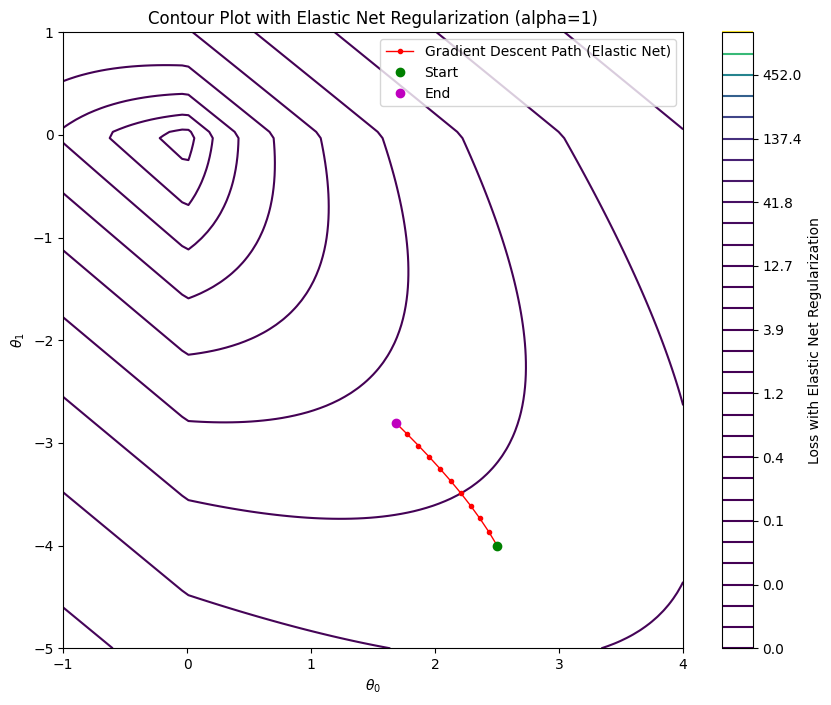

In [40]:
# Elastic Net Regularization

# Regularization parameters
lambda_reg = 1  # Overall regularization strength
alpha = 1       # Mixing parameter between L1 and L2 (alpha=0 => L2, alpha=1 => L1)

# Define the loss function with Elastic Net regularization
def compute_loss_en(theta, X, y, lambda_reg, alpha):
    mse = np.mean((X @ theta - y) ** 2)
    l1_penalty = lambda_reg * alpha * np.sum(np.abs(theta))
    l2_penalty = lambda_reg * (1 - alpha) * np.sum(theta ** 2)
    return mse + l1_penalty + l2_penalty

# Compute loss over the grid with Elastic Net regularization
Loss_en = np.zeros_like(Theta0)
for i in range(len(theta0_vals)):
    for j in range(len(theta1_vals)):
        theta = np.array([Theta0[j, i], Theta1[j, i]])
        Loss_en[j, i] = compute_loss_en(theta, X, y, lambda_reg, alpha)

# Adjust gradient descent function for Elastic Net regularization
def gradient_descent_en(X, y, theta_init, learning_rate, num_iters, lambda_reg, alpha):
    theta_history = [theta_init]
    theta = theta_init.copy()
    for _ in range(num_iters):
        gradient = (2 * X.T @ (X @ theta - y)) / len(y)
        # Elastic Net gradient
        l1_subgrad = lambda_reg * alpha * np.sign(theta)
        l2_grad = 2 * lambda_reg * (1 - alpha) * theta
        gradient += l1_subgrad + l2_grad
        theta = theta - learning_rate * gradient
        theta_history.append(theta.copy())
    return np.array(theta_history)

# Run gradient descent with Elastic Net regularization
theta_history_en = gradient_descent_en(X, y, theta_init, learning_rate, num_iters, lambda_reg, alpha)

# Plotting
plt.figure(figsize=(10, 8))
# Contour plot of the regularized loss function
contour_levels = np.logspace(-2, 3, 30)
plt.contour(Theta0, Theta1, Loss_en, levels=contour_levels, cmap='viridis')
plt.colorbar(label='Loss with Elastic Net Regularization')
# Overlay gradient descent path
plt.plot(theta_history_en[:, 0], theta_history_en[:, 1], 'ro-', markersize=3, linewidth=1, label='Gradient Descent Path (Elastic Net)')
# Mark the starting and ending points
plt.plot(theta_history_en[0, 0], theta_history_en[0, 1], 'go', label='Start')
plt.plot(theta_history_en[-1, 0], theta_history_en[-1, 1], 'mo', label='End')
# True theta
# plt.plot(theta_true[0], theta_true[1], 'yx', markersize=10, label='True Theta')
# Labels and title
plt.xlabel(r'$\theta_0$')
plt.ylabel(r'$\theta_1$')
plt.title(f'Contour Plot with Elastic Net Regularization (alpha={alpha})')
plt.legend()
plt.show()
